# Initial Data Exploration

In this section, I perform a preliminary analysis of the raw sales data to understand its structure, identify inconsistencies, and uncover patterns that will inform the data cleaning and transformation process. We'll inspect key columns such as customer names, invoice numbers, product descriptions, and totals, and assess common issues such as:

- Multi-line entries per invoice
- Inconsistent or ambiguous product labels (e.g., "HD", "High Dense", "N29/200")
- Spelling errors and data formatting issues

In [2]:
import pandas as pd

path = "../data/data.txt"

sales_df = pd.read_csv(path, on_bad_lines= "skip", encoding='cp1252')

/var/folders/qv/nw3vsgqx4kj68b4rlzsgkx540000gn/T/ipykernel_49304/4136353355.py:5: DtypeWarning: Columns (2,5) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv(path, on_bad_lines= "skip", encoding='cp1252')


Some lines have `,` in the description field, thus in this exploration I have opted to skip them

In [3]:
sales_df.head()

,Co./Last Name,Date,Invoice #,First Name,Item Number,Quantity,Description,Price,Total
0,Samantha Thomas,5/04/2025,00006814,NaN,Miscellaneous,1,"2""Outdoor 2 x 1000*1730(Z)",$527.27,$527.27
1,Samantha Thomas,5/04/2025,00006814,NaN,Dacron,2,Dacron,$54.545,$109.09
2,Samantha Thomas,5/04/2025,00006814,NaN,Miscellaneous,4,Sunbrella Payton,$70.91,$283.64
3,Samantha Thomas,5/04/2025,00006814,NaN,Miscellaneous,2.5,Vistaweave,$80.00,$200.00
4,Samantha Thomas,5/04/2025,00006814,NaN,Miscellaneous,2,Covers,$181.82,$363.64


In [4]:
sales_df.sample(n= 10)

,Co./Last Name,Date,Invoice #,First Name,Item Number,Quantity,Description,Price,Total
81777,Quetzalcoatl,2/12/2024,6615,NaN,"3""HD",1.0,"3"" 29/200 foam",$335.45,$335.45
48745,Lukas Matysek,14/01/2017,00051675,NaN,Miscellaneous,1,"2""Dryflow 2 pieces cut to templates",$190.91,$190.91
58681,Melinda,9/07/2019,00056651,NaN,Miscellaneous,3,3 x 1366 x 1090 x 150 mm thick indoor high den...,$266.3633,$799.09
7064,Cordingley,13/04/2010,00028702,Ben,"5""MD","2,500","2 pieces 23/130 5"", 25cm X 50cm",$0.0094,$22.73
31935,Bec,24/08/2013,00042395,NaN,Miscellaneous,1,Foam,$330.91,$330.91
44657,Virgina H,18/03/2016,00049350,NaN,"4""26/160",1,"4"" 26/160 Foam 1 piece cut to 189*76",$210.00,$210.00
65786,kylie summers,6/01/2021,60133,NaN,Miscellaneous,6.0,Dacron wadding for 6 pieces,$18.1817,$109.09
42200,Lara Pash,1/10/2015,00047983,NaN,Miscellaneous,6,sewing of 6 covers in clients fabric zipper on...,$50.00,$300.00
72000,Gavin and Nicole Basserabie,10/06/2022,1995,NaN,BSb,1.0,BSB 032 058 ACC 23 23 45,$0.00,$0.00
78988,Virginia Froebel,25/03/2024,5385,NaN,Miscellaneous,3.0,Dacron,$27.2733,$81.82


In [5]:
sales_df["Date"] = pd.to_datetime(sales_df["Date"], format="%d/%m/%Y")

#Removing the $ symbol
sales_df["Price"] = sales_df["Price"].str.replace("$", "", regex= False)
sales_df["Price"] = pd.to_numeric(sales_df["Price"], errors= "coerce")

sales_df["Total"] = sales_df["Total"].str.replace("$", "", regex= False)
sales_df["Total"] = pd.to_numeric(sales_df["Total"], errors= "coerce")

sales_df["Invoice #"] = pd.to_numeric(sales_df["Invoice #"], errors="coerce", downcast="integer")

sales_df["Quantity"] = pd.to_numeric(sales_df["Quantity"], errors="coerce", downcast="integer")


sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83107 entries, 0 to 83106
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Co./Last Name  83107 non-null  object        
 1   Date           83107 non-null  datetime64[ns]
 2   Invoice #      83106 non-null  float64       
 3   First Name     9760 non-null   object        
 4   Item Number    82447 non-null  object        
 5   Quantity       73225 non-null  float64       
 6   Description    82275 non-null  object        
 7   Price          81766 non-null  float64       
 8   Total          81644 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 5.7+ MB


In [6]:
sales_df["Item Number"].value_counts()[:15]

Item Number
Miscellaneous    40291
Discount          3009
Covers            1978
4"HD              1915
3"HD              1710
D18               1560
2"HD              1370
3"MD              1165
4"MD              1090
2"MD              1081
D25                924
Delivery           907
D35                899
5"HD               677
BSb                671
Name: count, dtype: int64

In [7]:
sales_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Co./Last Name,83107,22969,Able & Carriage,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,83107,NaN,NaN,NaN,2016-03-21 12:21:24.454980096,2006-11-09 00:00:00,2011-12-13 00:00:00,2015-08-18 00:00:00,2020-05-18 00:00:00,2025-05-02 00:00:00,NaN
Invoice #,83106.0,NaN,NaN,NaN,36371.261894,351.0,28095.25,39538.5,50796.0,61316.0,17968.042973
First Name,9760,1358,"Gerhardt,",220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Number,82447,493,Miscellaneous,40291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,73225.0,NaN,NaN,NaN,4.802769,-17.0,1.0,1.0,2.0,999.0,41.844179
Description,82275,45698,Dacron,5042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,81766.0,NaN,NaN,NaN,95.33334,0.0,16.36,47.27,118.18,999.09,134.450686
Total,81644.0,NaN,NaN,NaN,135.579756,-983.64,36.36,86.36,181.81,999.09,166.304355


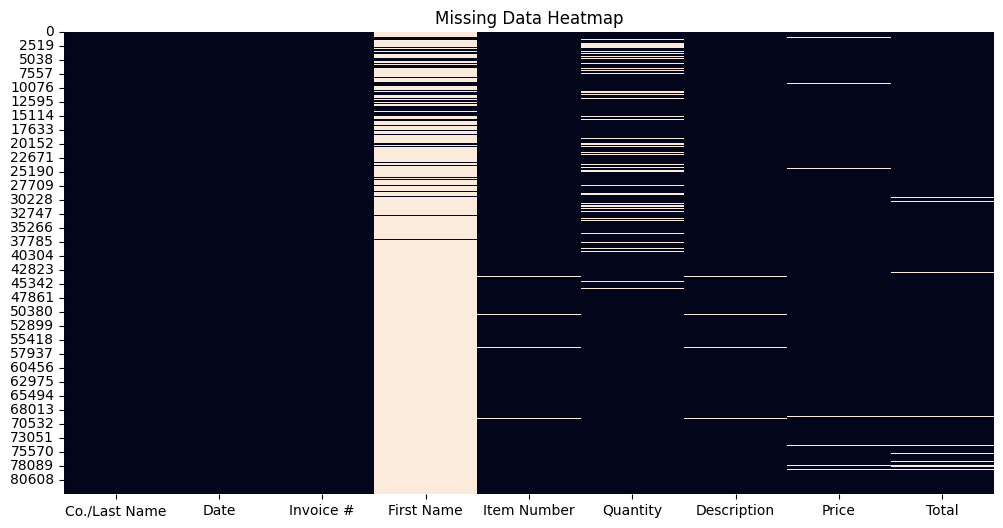

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(sales_df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

From this heat map it can be seen that there the majority of the First Name Field has not been defined as well as some coloumns Intem Number and Description

<Axes: >

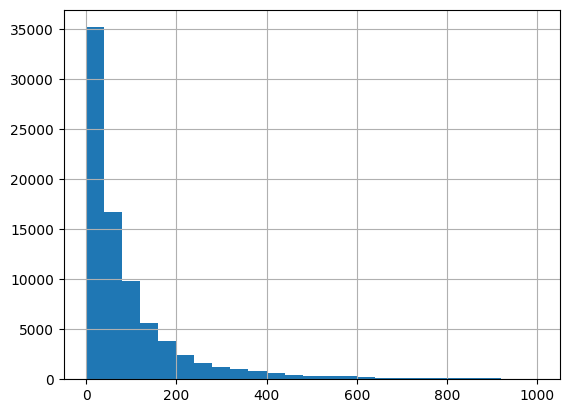

In [9]:

sales_df["Price"].hist(bins=25)

In [13]:
sales_df.nlargest(10, "Price")

,Co./Last Name,Date,Invoice #,First Name,Item Number,Quantity,Description,Price,Total
34368,Jo Capal,2014-01-29,43639.0,NaN,Miscellaneous,1.0,We owe 5 x Wedges,999.09,999.09
57867,Fiona Rowles,2019-04-15,56236.0,NaN,Miscellaneous,1.0,one double hard dreamer,999.09,999.09
69920,Kirsty Duncker,2021-11-23,1060.0,NaN,Miscellaneous,1.0,3 @ 1080 x 910 x 150mm DRICELL outdoor N27/120...,998.18,998.18
70522,Karen Remely,2022-01-20,1377.0,NaN,Miscellaneous,1.0,"2 x 450(z)mmx460mm x 50mm,4 x 510(z)mmx460mmx...",997.27,997.27
62516,Callie Ford,2020-05-27,58551.0,NaN,Miscellaneous,1.0,"3383 x 640 x 75 mm dryflow , 2000 x 637 x 75 m...",996.36,996.36
70872,Rob Rawson,2022-02-22,1528.0,NaN,Miscellaneous,1.0,2 @ 110 x 86 x 12.5 cm dryflwo 2 @ 75 x 86 x ...,996.36,996.36
12234,Brown,2010-11-16,31566.0,Peter,Miscellaneous,1.0,King mattress visco 20cm,995.45,995.45
55226,Dunban,2018-09-01,54880.0,NaN,"S6""30/130",1.0,visco mattress king (no cover) 1750 x 2030,995.45,995.45
74869,Tamara Schwarz,2023-02-06,3397.0,NaN,Miscellaneous,1.0,single dreamer,995.45,995.45
5403,Kelleher,2010-02-04,27718.0,Kelleher,Miscellaneous,1.0,"Dryflow 3 Sheets 4"" MEDIUM thick cut to, 4 pie...",990.91,990.91


### Saving the relevant data for my next stage
Due to the majority of entries for `First Name` are null, I have decided to drop this column

In [14]:
final_df = sales_df.drop("First Name", axis=1)
final_df.to_csv("../data/stage_1_output.txt")